# Day 16 - Analisis Pengiriman (Shipment Delivery Analysis)

**Program:** Capstone Anteraja - Minggu 4 (Data)
**Tools:** Google Colab - pandas - NumPy - Matplotlib - scikit-learn

Notebook ini mengerjakan seluruh alur Day 16:

1. Fundamental Python (variabel, list, dictionary, kondisi, loop)
2. Memuat dan membersihkan data pengiriman dengan Pandas
3. Menghitung statistik `delay_hours` dengan NumPy
4. Grouping rata-rata keterlambatan per kurir (loop manual vs `groupby()`)
5. Visualisasi Matplotlib dan analisis korelasi
6. Melatih model Linear Regression untuk memprediksi `delay_hours`
7. Membandingkan keterlambatan jarak jauh vs jarak dekat, lalu menarik satu insight bisnis

## 0. Fundamental Python

Sebelum menyentuh Pandas, kita latihan konsep dasarnya dulu: **variabel**, **list**, **dictionary**,
**kondisi**, dan **loop**. Datanya masih kecil dan ditulis manual supaya alurnya jelas.

In [1]:
# Variabel dan tipe data dasar
nama_program = "Day 16 - Shipment Delivery Analysis"
hari_ke = 16
sudah_dijalankan = False

print(nama_program, "| hari ke-", hari_ke, "| sudah dijalankan?", sudah_dijalankan)

# List berisi dictionary: cara paling sederhana menyimpan beberapa baris data pengiriman
contoh_pengiriman = [
    {"tracking_number": "AJ2500000001", "courier": "JNE", "distance_km": 8.5,
     "promised_hours": 24, "actual_hours": 24.6},
    {"tracking_number": "AJ2500000002", "courier": "Ninja Xpress", "distance_km": 62.0,
     "promised_hours": 48, "actual_hours": 51.4},
    {"tracking_number": "AJ2500000003", "courier": "SiCepat", "distance_km": 41.2,
     "promised_hours": 48, "actual_hours": 49.1},
    {"tracking_number": "AJ2500000004", "courier": "AnterAja", "distance_km": 95.7,
     "promised_hours": 72, "actual_hours": 76.8},
]

print("Jumlah contoh pengiriman:", len(contoh_pengiriman))
print("Contoh pertama:", contoh_pengiriman[0])

Day 16 - Shipment Delivery Analysis | hari ke- 16 | sudah dijalankan? False
Jumlah contoh pengiriman: 4
Contoh pertama: {'tracking_number': 'AJ2500000001', 'courier': 'JNE', 'distance_km': 8.5, 'promised_hours': 24, 'actual_hours': 24.6}


In [2]:
BATAS_TELAT_JAM = 2  # kiriman dianggap terlambat kalau selisihnya lebih dari 2 jam

jumlah_telat = 0

for kiriman in contoh_pengiriman:
    selisih_jam = kiriman["actual_hours"] - kiriman["promised_hours"]

    if selisih_jam > BATAS_TELAT_JAM:
        status = "TELAT"
        jumlah_telat += 1
    else:
        status = "TEPAT WAKTU"

    print(f"{kiriman['tracking_number']} | {kiriman['courier']:<13} | selisih {selisih_jam:+5.1f} jam | {status}")

print(f"\n{jumlah_telat} dari {len(contoh_pengiriman)} kiriman contoh terlambat lebih dari {BATAS_TELAT_JAM} jam.")

AJ2500000001 | JNE           | selisih  +0.6 jam | TEPAT WAKTU
AJ2500000002 | Ninja Xpress  | selisih  +3.4 jam | TELAT
AJ2500000003 | SiCepat       | selisih  +1.1 jam | TEPAT WAKTU
AJ2500000004 | AnterAja      | selisih  +4.8 jam | TELAT

2 dari 4 kiriman contoh terlambat lebih dari 2 jam.


## 1. Setup dan Memuat Dataset

Dataset berisi ratusan baris pengiriman dengan kolom
`tracking_number, courier, weight_kg, distance_km, promised_hours, actual_hours`.

File `shipments.csv` di folder ini dihasilkan oleh fungsi `generate_shipments()` di bawah
dengan seed tetap, jadi isinya selalu sama dan bisa diregenerasi kapan saja. Versi yang di-commit
memang sengaja "kotor" (ada nilai kosong, nilai desimal berkoma, dan baris duplikat) supaya proses
cleaning di section 3 benar-benar teruji.

Kalau notebook ini dibuka di sesi Google Colab baru dan `shipments.csv` belum ada, sel di bawah
akan membuat ulang file yang identik secara otomatis. Kalau Anda punya file dataset resmi dari Drive,
cukup unggah filenya dengan nama `shipments.csv` supaya dipakai sebagai gantinya.

In [3]:
# Semua library di bawah sudah tersedia di Google Colab, jadi tidak perlu pip install.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

%matplotlib inline

RANDOM_STATE = 42
DATA_PATH = "shipments.csv"

# Bias keterlambatan bawaan tiap kurir (jam) supaya performa antar kurir berbeda.
COURIER_BIAS = {
    "JNE": 0.20,
    "J&T": 0.35,
    "AnterAja": 0.30,
    "SiCepat": 0.55,
    "Pos Indonesia": 0.80,
    "Ninja Xpress": 1.10,
}
COURIER_SHARE = [0.22, 0.20, 0.14, 0.16, 0.15, 0.13]  # urutannya sama dengan COURIER_BIAS


def generate_shipments(seed=RANDOM_STATE, n=500):
    # Membuat dataset simulasi pengiriman; hasilnya deterministik untuk seed yang sama.
    rng = np.random.default_rng(seed)

    courier = rng.choice(list(COURIER_BIAS), size=n, p=COURIER_SHARE)
    distance_km = np.clip(rng.lognormal(mean=2.75, sigma=0.95, size=n), 1.0, 120.0)
    weight_kg = np.clip(rng.lognormal(mean=1.05, sigma=0.60, size=n), 0.30, 30.0)

    # Janji layanan: 24 jam (dekat), 48 jam (menengah), 72 jam (jauh).
    promised_hours = np.where(distance_km < 25, 24, np.where(distance_km < 75, 48, 72))

    bias = np.array([COURIER_BIAS[kurir] for kurir in courier])
    noise = rng.normal(loc=0.0, scale=0.80, size=n)

    # Keterlambatan naik seiring jarak; berat paket hanya memberi efek kecil.
    delay = 0.55 + 0.019 * distance_km + bias + noise + 0.02 * weight_kg
    actual_hours = promised_hours + delay

    df = pd.DataFrame({
        "tracking_number": [f"AJ2510{i:06d}" for i in range(1, n + 1)],
        "courier": courier,
        "weight_kg": np.round(weight_kg, 2),
        "distance_km": np.round(distance_km, 2),
        "promised_hours": promised_hours.astype(float),
        "actual_hours": np.round(actual_hours, 2),
    })

    # --- Bagian berikut sengaja mengotori data supaya cleaning punya pekerjaan nyata ---
    dirty_rng = np.random.default_rng(seed + 1)
    kolom_dirty = ["weight_kg", "distance_km", "promised_hours", "actual_hours", "courier"]

    baris_kosong = dirty_rng.choice(df.index, size=8, replace=False)
    for urutan, baris in enumerate(baris_kosong):
        df.loc[baris, kolom_dirty[urutan % len(kolom_dirty)]] = np.nan

    # Kolom numerik diubah ke object dulu supaya bisa menampung nilai teks seperti "12,4" atau "N/A".
    df["distance_km"] = df["distance_km"].astype(object)
    df["weight_kg"] = df["weight_kg"].astype(object)

    baris_koma = dirty_rng.choice(df.index.difference(baris_kosong), size=4, replace=False)
    for baris in baris_koma:
        df.loc[baris, "distance_km"] = f"{float(df.loc[baris, 'distance_km']):.1f}".replace(".", ",")

    baris_na = dirty_rng.choice(
        df.index.difference(np.concatenate([baris_kosong, baris_koma])), size=3, replace=False
    )
    for baris in baris_na:
        df.loc[baris, "weight_kg"] = "N/A"

    # 25 baris duplikat
    df = pd.concat([df, df.sample(25, random_state=seed + 2)], ignore_index=True)
    return df


print("Fungsi generate_shipments() siap dipakai.")

Fungsi generate_shipments() siap dipakai.


In [4]:
from pathlib import Path

if not Path(DATA_PATH).exists():
    # Fallback sesi Google Colab baru: buat ulang dataset yang identik, lalu dibaca dari file
    # supaya hasilnya sama persis dengan jalur normal.
    generate_shipments().to_csv(DATA_PATH, index=False)
    print(f"File {DATA_PATH} belum ada, dataset dibuat ulang dengan generate_shipments().")

df_raw = pd.read_csv(DATA_PATH)
print(f"Dataset dimuat dari {DATA_PATH}: {df_raw.shape[0]} baris x {df_raw.shape[1]} kolom")

Dataset dimuat dari shipments.csv: 525 baris x 6 kolom


In [5]:
df_raw.head()

,tracking_number,courier,weight_kg,distance_km,promised_hours,actual_hours
0,AJ2510000001,Pos Indonesia,1.14,61.04,48.0,50.98
1,AJ2510000002,AnterAja,3.28,17.06,24.0,25.33
2,AJ2510000003,Pos Indonesia,4.44,27.16,48.0,50.22
3,AJ2510000004,SiCepat,3.58,14.82,24.0,26.08
4,AJ2510000005,JNE,4.18,13.3,24.0,24.44


## 2. Mengenal Kondisi Data (EDA)

Sebelum dibersihkan, kita lihat dulu ukuran data, tipe kolom, nilai kosong, dan duplikatnya. Ini
penting supaya tahu masalah apa saja yang harus dibereskan.

In [6]:
print("Ukuran data (baris, kolom):", df_raw.shape)

print("\nInfo kolom dan tipe data:")
df_raw.info()

print("\nJumlah nilai kosong per kolom:")
print(df_raw.isna().sum())

print("\nTotal nilai kosong   :", int(df_raw.isna().sum().sum()))
print("Total baris duplikat :", int(df_raw.duplicated().sum()))

Ukuran data (baris, kolom): (525, 6)

Info kolom dan tipe data:
<class 'pandas.DataFrame'>
RangeIndex: 525 entries, 0 to 524
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tracking_number  525 non-null    str    
 1   courier          524 non-null    str    
 2   weight_kg        520 non-null    float64
 3   distance_km      523 non-null    str    
 4   promised_hours   523 non-null    float64
 5   actual_hours     524 non-null    float64
dtypes: float64(3), str(3)
memory usage: 24.7 KB

Jumlah nilai kosong per kolom:
tracking_number    0
courier            1
weight_kg          5
distance_km        2
promised_hours     2
actual_hours       1
dtype: int64

Total nilai kosong   : 11
Total baris duplikat : 25


## 3. Membersihkan Data

Tiga langkah yang dilakukan:

1. **Perbaiki tipe kolom numerik.** Kolom `distance_km` dan `weight_kg` terbaca sebagai teks
   karena ada nilai seperti `"12,5"` dan `"N/A"`. Koma desimal diubah ke titik, lalu
   `pd.to_numeric(errors="coerce")` memaksa kolomnya jadi angka (nilai yang tidak bisa dibaca
   berubah menjadi `NaN`).
2. **Hapus baris kosong** dengan `dropna()`.
3. **Buang baris duplikat** dengan `drop_duplicates()`.

In [7]:
df = df_raw.copy()

kolom_numerik = ["weight_kg", "distance_km", "promised_hours", "actual_hours"]

for kolom in kolom_numerik:
    df[kolom] = pd.to_numeric(
        df[kolom].astype(str).str.replace(",", ".", regex=False),
        errors="coerce",
    )

print("Tipe data setelah perbaikan tipe:")
print(df[["courier"] + kolom_numerik].dtypes)

Tipe data setelah perbaikan tipe:
courier               str
weight_kg         float64
distance_km       float64
promised_hours    float64
actual_hours      float64
dtype: object


In [8]:
baris_sebelum = df.shape[0]

df = df.dropna().drop_duplicates().reset_index(drop=True)

laporan_cleaning = {
    "Baris sebelum dibersihkan": baris_sebelum,
    "Baris setelah dibersihkan": len(df),
    "Nilai kosong tersisa": int(df.isna().sum().sum()),
    "Baris duplikat tersisa": int(df.duplicated().sum()),
}

for label, nilai in laporan_cleaning.items():
    print(f"{label:<28}: {nilai}")

assert laporan_cleaning["Nilai kosong tersisa"] == 0, "Masih ada nilai kosong!"
assert laporan_cleaning["Baris duplikat tersisa"] == 0, "Masih ada baris duplikat!"

print("\nValidasi lolos: data bersih, tanpa nilai kosong maupun duplikat.")
print("\nTipe data akhir:")
print(df.dtypes)

Baris sebelum dibersihkan   : 525
Baris setelah dibersihkan   : 489
Nilai kosong tersisa        : 0
Baris duplikat tersisa      : 0

Validasi lolos: data bersih, tanpa nilai kosong maupun duplikat.

Tipe data akhir:
tracking_number        str
courier                str
weight_kg          float64
distance_km        float64
promised_hours     float64
actual_hours       float64
dtype: object


## 4. Kolom Baru `delay_hours`

`delay_hours = actual_hours - promised_hours`, lalu dipotong di batas bawah 0 dengan
`clip(lower=0)` supaya kiriman yang datang lebih cepat tidak menghasilkan nilai minus.

In [9]:
df["delay_hours"] = (df["actual_hours"] - df["promised_hours"]).clip(lower=0)

tepat_waktu = int((df["delay_hours"] == 0).sum())

print(f"Nilai delay_hours terkecil : {df['delay_hours'].min():.2f} jam")
print(f"Kiriman datang lebih cepat : {tepat_waktu} dari {len(df)} (delay_hours = 0)")

assert df["delay_hours"].min() >= 0, "delay_hours tidak boleh minus!"
print("Validasi lolos: tidak ada delay_hours yang minus.")

df[["tracking_number", "courier", "distance_km", "weight_kg", "promised_hours", "actual_hours", "delay_hours"]].head()

Nilai delay_hours terkecil : 0.00 jam
Kiriman datang lebih cepat : 35 dari 489 (delay_hours = 0)
Validasi lolos: tidak ada delay_hours yang minus.


,tracking_number,courier,distance_km,weight_kg,promised_hours,actual_hours,delay_hours
0,AJ2510000001,Pos Indonesia,61.04,1.14,48.0,50.98,2.98
1,AJ2510000002,AnterAja,17.06,3.28,24.0,25.33,1.33
2,AJ2510000003,Pos Indonesia,27.16,4.44,48.0,50.22,2.22
3,AJ2510000004,SiCepat,14.82,3.58,24.0,26.08,2.08
4,AJ2510000005,JNE,13.30,4.18,24.0,24.44,0.44


## 5. Statistik `delay_hours` dengan NumPy

Minimum, median, mean, dan standar deviasi dihitung memakai fungsi NumPy (`np.min`,
`np.median`, `np.mean`, `np.std`), ditambah P90 sebagai gambaran ekor distribusinya.

In [10]:
delay = df["delay_hours"].to_numpy()

statistik_delay = {
    "minimum": np.min(delay),
    "median": np.median(delay),
    "mean": np.mean(delay),
    "std": np.std(delay),
    "persentil 90": np.percentile(delay, 90),
    "maksimum": np.max(delay),
}

for label, nilai in statistik_delay.items():
    print(f"{label:<13}: {nilai:.2f} jam")

minimum      : 0.00 jam
median       : 1.43 jam
mean         : 1.44 jam
std          : 0.88 jam
persentil 90 : 2.57 jam
maksimum     : 4.65 jam


## 6. Grouping: Rata-rata Keterlambatan per Kurir

Rata-rata `delay_hours` per kurir dihitung dengan dua cara: **loop manual** (dictionary sebagai
akumulator) dan **`groupby()`**. Hasil keduanya dibandingkan supaya yakin sama.

In [11]:
total_delay = {}
jumlah_kiriman = {}

for kurir, delay_jam in zip(df["courier"], df["delay_hours"]):
    total_delay[kurir] = total_delay.get(kurir, 0.0) + delay_jam
    jumlah_kiriman[kurir] = jumlah_kiriman.get(kurir, 0) + 1

rata_delay_loop = {kurir: total_delay[kurir] / jumlah_kiriman[kurir] for kurir in total_delay}

print("Hasil loop manual:")
for kurir in sorted(rata_delay_loop, key=rata_delay_loop.get, reverse=True):
    print(f"  {kurir:<15} {rata_delay_loop[kurir]:5.2f} jam ({jumlah_kiriman[kurir]} kiriman)")

Hasil loop manual:
  Ninja Xpress     1.97 jam (54 kiriman)
  Pos Indonesia    1.82 jam (79 kiriman)
  SiCepat          1.49 jam (89 kiriman)
  J&T              1.25 jam (88 kiriman)
  AnterAja         1.22 jam (65 kiriman)
  JNE              1.17 jam (114 kiriman)


In [12]:
rata_delay_groupby = df.groupby("courier")["delay_hours"].mean().sort_values(ascending=False)

print("Hasil groupby():")
print(rata_delay_groupby.round(2).to_string())

urutan = sorted(rata_delay_loop)
hasil_loop = np.array([rata_delay_loop[kurir] for kurir in urutan])
hasil_groupby = rata_delay_groupby.loc[urutan].to_numpy()

sama = np.allclose(hasil_loop, hasil_groupby)
print(f"\nHasil loop manual identik dengan groupby(): {sama}")
assert sama, "Hasil loop manual dan groupby() berbeda!"

kurir_terburuk = rata_delay_groupby.idxmax()
print(f"Kurir dengan rata-rata keterlambatan tertinggi: {kurir_terburuk} ({rata_delay_groupby.max():.2f} jam)")

Hasil groupby():
courier
Ninja Xpress     1.97
Pos Indonesia    1.82
SiCepat          1.49
J&T              1.25
AnterAja         1.22
JNE              1.17

Hasil loop manual identik dengan groupby(): True
Kurir dengan rata-rata keterlambatan tertinggi: Ninja Xpress (1.97 jam)


## 7. Visualisasi: Rata-rata Keterlambatan per Kurir

Bar chart Matplotlib dengan kurir terburuk disorot warna merah.

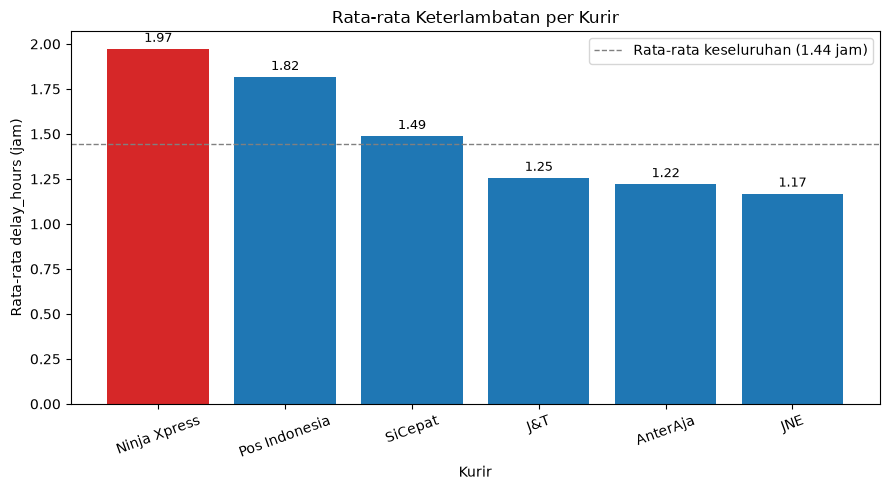

Grafik disimpan sebagai delay-per-courier.png (kurir terburuk: Ninja Xpress)


In [13]:
warna = ["#d62728" if kurir == kurir_terburuk else "#1f77b4" for kurir in rata_delay_groupby.index]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(rata_delay_groupby.index, rata_delay_groupby.to_numpy(), color=warna)
ax.axhline(np.mean(delay), color="gray", linestyle="--", linewidth=1,
           label=f"Rata-rata keseluruhan ({np.mean(delay):.2f} jam)")
ax.set_title("Rata-rata Keterlambatan per Kurir")
ax.set_xlabel("Kurir")
ax.set_ylabel("Rata-rata delay_hours (jam)")

for posisi, nilai in enumerate(rata_delay_groupby.to_numpy()):
    ax.text(posisi, nilai + 0.04, f"{nilai:.2f}", ha="center", fontsize=9)

ax.legend()
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("delay-per-courier.png", dpi=110)
plt.show()

print(f"Grafik disimpan sebagai delay-per-courier.png (kurir terburuk: {kurir_terburuk})")

## 8. Korelasi Jarak Tempuh dan Berat Paket terhadap Keterlambatan

Korelasi dihitung dengan `corr()` (Pearson) dan dibandingkan dengan `np.corrcoef()`, untuk
melihat variabel mana yang paling berpengaruh terhadap `delay_hours`.

In [14]:
matriks_korelasi = df[["distance_km", "weight_kg", "delay_hours"]].corr()
print("Matriks korelasi:")
print(matriks_korelasi.round(3).to_string())

r_jarak = np.corrcoef(df["distance_km"], df["delay_hours"])[0, 1]
r_berat = np.corrcoef(df["weight_kg"], df["delay_hours"])[0, 1]

print(f"\nKorelasi distance_km vs delay_hours: {r_jarak:+.3f}")
print(f"Korelasi weight_kg   vs delay_hours: {r_berat:+.3f}")

paling_berpengaruh = "jarak" if abs(r_jarak) > abs(r_berat) else "berat"
print(f"\nKesimpulan sementara: {paling_berpengaruh} lebih berpengaruh terhadap keterlambatan.")

Matriks korelasi:
             distance_km  weight_kg  delay_hours
distance_km        1.000      0.029        0.393
weight_kg          0.029      1.000        0.046
delay_hours        0.393      0.046        1.000

Korelasi distance_km vs delay_hours: +0.393
Korelasi weight_kg   vs delay_hours: +0.046

Kesimpulan sementara: jarak lebih berpengaruh terhadap keterlambatan.


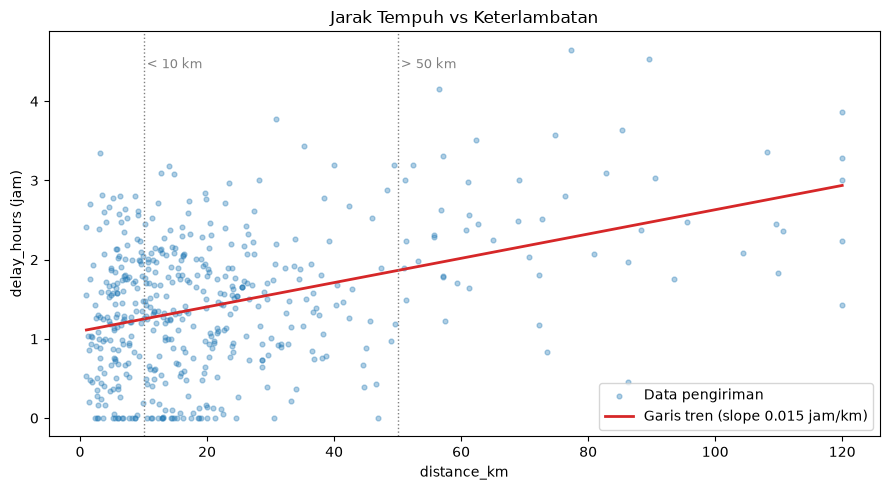

Grafik disimpan sebagai delay-vs-distance.png


In [15]:
jarak = df["distance_km"].to_numpy()
koefisien_tren = np.polyfit(jarak, delay, 1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(jarak, delay, s=12, alpha=0.35, label="Data pengiriman")

garis_x = np.linspace(jarak.min(), jarak.max(), 100)
ax.plot(garis_x, np.polyval(koefisien_tren, garis_x), color="#d62728", linewidth=2,
        label=f"Garis tren (slope {koefisien_tren[0]:.3f} jam/km)")

ax.axvline(10, color="gray", linestyle=":", linewidth=1)
ax.axvline(50, color="gray", linestyle=":", linewidth=1)
ax.text(10.5, delay.max() * 0.95, "< 10 km", fontsize=9, color="gray")
ax.text(50.5, delay.max() * 0.95, "> 50 km", fontsize=9, color="gray")

ax.set_title("Jarak Tempuh vs Keterlambatan")
ax.set_xlabel("distance_km")
ax.set_ylabel("delay_hours (jam)")
ax.legend()
plt.tight_layout()
plt.savefig("delay-vs-distance.png", dpi=110)
plt.show()

print("Grafik disimpan sebagai delay-vs-distance.png")

## 9. Model Linear Regression

Data dibagi 80% latih dan 20% uji. Fitur yang dipakai `distance_km` dan `weight_kg`,
targetnya `delay_hours`. Evaluasi memakai MAE, RMSE, dan R-squared.

Nilai R-squared yang moderat wajar di sini: jarak dan berat saja belum cukup menjelaskan
keterlambatan, sehingga sinyal operasional lain (SLA per kurir, kepadatan hub, jam sibuk) masih
perlu ditambahkan sebelum model ini dipakai untuk keputusan operasional.

In [16]:
fitur = ["distance_km", "weight_kg"]
X = df[fitur].to_numpy()
y = df["delay_hours"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Data latih : {X_train.shape[0]} baris")
print(f"Data uji   : {X_test.shape[0]} baris")
print(f"\nMAE  : {mae:.3f} jam")
print(f"RMSE : {rmse:.3f} jam")
print(f"R2   : {r2:.3f}")

print(f"\nIntercept: {model.intercept_:.3f} jam")
for nama_fitur, koefisien in zip(fitur, model.coef_):
    print(f"  {nama_fitur:<12}: {koefisien:+.4f} jam per satuan")

print("\nContoh prediksi pada 5 kiriman uji:")
for aktual, prediksi in list(zip(y_test, y_pred))[:5]:
    print(f"  aktual {aktual:5.2f} jam | prediksi {prediksi:5.2f} jam | selisih {prediksi - aktual:+5.2f} jam")

Data latih : 391 baris
Data uji   : 98 baris

MAE  : 0.653 jam
RMSE : 0.785 jam
R2   : 0.116

Intercept: 1.094 jam
  distance_km : +0.0155 jam per satuan
  weight_kg   : +0.0119 jam per satuan

Contoh prediksi pada 5 kiriman uji:
  aktual  0.97 jam | prediksi  1.93 jam | selisih +0.96 jam
  aktual  1.71 jam | prediksi  1.27 jam | selisih -0.44 jam
  aktual  1.76 jam | prediksi  2.56 jam | selisih +0.80 jam
  aktual  0.70 jam | prediksi  1.39 jam | selisih +0.69 jam
  aktual  0.28 jam | prediksi  1.17 jam | selisih +0.89 jam


In [17]:
BATAS_TELAT_JAM = 2
AMBANG_JAUH_KM = 50
AMBANG_DEKAT_KM = 10

df["is_late"] = df["delay_hours"] > BATAS_TELAT_JAM

pengiriman_jauh = df[df["distance_km"] > AMBANG_JAUH_KM]
pengiriman_dekat = df[df["distance_km"] < AMBANG_DEKAT_KM]

rate_jauh = pengiriman_jauh["is_late"].mean()
rate_dekat = pengiriman_dekat["is_late"].mean()
rata_delay_jauh = pengiriman_jauh["delay_hours"].mean()
rata_delay_dekat = pengiriman_dekat["delay_hours"].mean()
rasio = rate_jauh / rate_dekat

ringkasan = {
    f"Jauh (>{AMBANG_JAUH_KM} km)": (len(pengiriman_jauh), rate_jauh, rata_delay_jauh),
    f"Dekat (<{AMBANG_DEKAT_KM} km)": (len(pengiriman_dekat), rate_dekat, rata_delay_dekat),
}

print(f"{'Kelompok':<18}{'Jumlah':>8}{'Rate terlambat':>16}{'Rata-rata delay':>18}")
for label, (jumlah, rate, rata) in ringkasan.items():
    print(f"{label:<18}{jumlah:>8}{rate * 100:>15.1f}%{rata:>16.2f} jam")

print(f"\nRate keterlambatan jarak jauh {rasio:.1f}x lebih tinggi daripada jarak dekat.")

insight_bisnis = (
    f"Pengiriman di atas {AMBANG_JAUH_KM} km terlambat lebih dari {BATAS_TELAT_JAM} jam "
    f"{rasio:.1f}x lebih sering ({rate_jauh * 100:.1f}% vs {rate_dekat * 100:.1f}%), dengan rata-rata "
    f"keterlambatan {rata_delay_jauh:.2f} jam vs {rata_delay_dekat:.2f} jam, sehingga rute jarak jauh "
    f"perlu buffer waktu janji dan prioritas pemantauan tersendiri."
)
print("\nInsight:", insight_bisnis)

Kelompok            Jumlah  Rate terlambat   Rata-rata delay
Jauh (>50 km)           52           69.2%            2.48 jam
Dekat (<10 km)         158           18.4%            1.26 jam

Rate keterlambatan jarak jauh 3.8x lebih tinggi daripada jarak dekat.

Insight: Pengiriman di atas 50 km terlambat lebih dari 2 jam 3.8x lebih sering (69.2% vs 18.4%), dengan rata-rata keterlambatan 2.48 jam vs 1.26 jam, sehingga rute jarak jauh perlu buffer waktu janji dan prioritas pemantauan tersendiri.


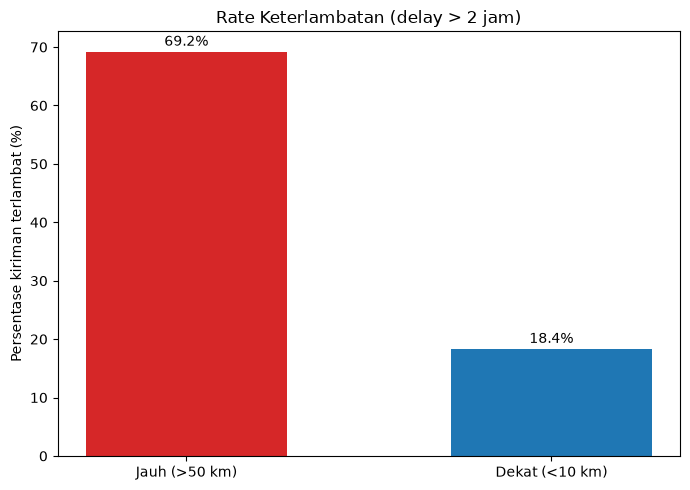

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(
    [f"Jauh (>{AMBANG_JAUH_KM} km)", f"Dekat (<{AMBANG_DEKAT_KM} km)"],
    [rate_jauh * 100, rate_dekat * 100],
    color=["#d62728", "#1f77b4"],
    width=0.55,
)
ax.set_title(f"Rate Keterlambatan (delay > {BATAS_TELAT_JAM} jam)")
ax.set_ylabel("Persentase kiriman terlambat (%)")

for posisi, nilai in enumerate([rate_jauh * 100, rate_dekat * 100]):
    ax.text(posisi, nilai + 1, f"{nilai:.1f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

## 10. Insight Bisnis

> **Pengiriman di atas 50 km terlambat lebih dari 2 jam 3.8x lebih sering (69.2% vs 18.4%), dengan rata-rata keterlambatan 2.48 jam vs 1.26 jam, sehingga rute jarak jauh perlu buffer waktu janji dan prioritas pemantauan tersendiri.**

Jarak tempuh berkorelasi positif dengan keterlambatan, sedangkan berat paket hampir tidak
berpengaruh. Artinya sumber masalahnya ada di rute, bukan di ukuran paket.

## 11. Ringkasan Validasi

- Dataset dimuat dan dibersihkan: **0 nilai kosong** dan **0 baris duplikat** yang tersisa.
- Statistik `delay_hours` (minimum, median, mean, std) dihitung dengan fungsi NumPy.
- Visualisasi Matplotlib tersedia: bar chart rata-rata keterlambatan per kurir
  (`delay-per-courier.png`) dan scatter jarak vs keterlambatan (`delay-vs-distance.png`).
- Grouping menemukan kurir dengan rata-rata keterlambatan tertinggi, dan hasil loop manual
  terbukti identik dengan `groupby()`.
- Korelasi dua variabel dibandingkan, lalu model Linear Regression dilatih dan dievaluasi
  (MAE, RMSE, R-squared).
- Insight bisnis ditulis berdasarkan komparasi persentase keterlambatan jarak jauh vs dekat.